# Clasificador de solicitudes: ML clásico frente a LLM

**Paso 07 · Pilar 1 (Fundamentos de ML) + Pilar 4 (Tomar decisiones de producto)**

Pregunta: para encuadrar una solicitud en una de las 3 líneas del centro, ¿conviene un modelo clásico (TF-IDF + regresión logística) o un LLM (Claude Haiku 4.5)? Comparamos **en el mismo conjunto de prueba**: accuracy, F1 macro, costo por 1.000 clasificaciones y latencia.

> ⚠️ **Datos sintéticos.** Las 120 solicitudes de `ml/data/requests_labeled.csv` las escribió Claude (`scripts/ml/generate-requests.ts`) a partir de una línea dada, así que la etiqueta viene del pedido de generación. Una muestra de 18 filas fue revisada por el agente de código (`ml/data/muestra-revisada.csv`): 16 de acuerdo y 2 ambiguas. **Falta la revisión humana.** Los números de este notebook miden el comportamiento en datos sintéticos, no en solicitudes reales.

In [1]:
import json, re, time, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.pipeline import make_pipeline, make_union
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

ROOT = Path.cwd().parent if Path.cwd().name == "ml" else Path.cwd()
OUT = ROOT / "ml" / "results"
OUT.mkdir(parents=True, exist_ok=True)
LINES = ["quality_assurance", "business_innovation", "process_design"]
plt.rcParams.update({"font.family": "Arial", "figure.dpi": 110})

df = pd.read_csv(ROOT / "ml" / "data" / "requests_labeled.csv")
print(df.shape)
df.line.value_counts()

(120, 6)


line
quality_assurance      40
business_innovation    40
process_design         40
Name: count, dtype: int64

## 1. División train / test estratificada

70 % para entrenar y 30 % para probar, **estratificado** (la misma proporción de cada línea en ambos lados) y con semilla fija para que el resultado sea reproducible. El conjunto de prueba es el mismo para todos los modelos.

In [2]:
train, test = train_test_split(df, test_size=0.3, stratify=df.line, random_state=42)
print("train:", len(train), dict(train.line.value_counts()))
print("test: ", len(test), dict(test.line.value_counts()))

train: 84 {'quality_assurance': np.int64(28), 'process_design': np.int64(28), 'business_innovation': np.int64(28)}
test:  36 {'process_design': np.int64(12), 'quality_assurance': np.int64(12), 'business_innovation': np.int64(12)}


## 2. Modelo clásico: TF-IDF + regresión logística

- **TF-IDF** convierte cada texto en un vector: palabras (y pares de palabras) que son frecuentes en ese texto pero raras en el conjunto pesan más.
- Sumamos n-gramas de **caracteres** (3 a 5), que toleran faltas de ortografía y variantes ("despelote", "desperdicio", "desperdiciamos").
- **Regresión logística**: un clasificador lineal que aprende un peso por cada rasgo y línea.

In [3]:
clf = make_pipeline(
    make_union(
        TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True, min_df=1),
        TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), sublinear_tf=True, min_df=2),
    ),
    LogisticRegression(max_iter=3000, C=5.0),
)
t0 = time.perf_counter(); clf.fit(train.text, train.line); fit_s = time.perf_counter() - t0

pred_train = clf.predict(train.text)
lat = []
pred_tfidf = []
for t in test.text:
    s = time.perf_counter(); pred_tfidf.append(clf.predict([t])[0]); lat.append((time.perf_counter() - s) * 1000)

tfidf = {
    "name": "TF-IDF + LogReg",
    "accuracy": accuracy_score(test.line, pred_tfidf),
    "macro_f1": f1_score(test.line, pred_tfidf, average="macro"),
    "train_accuracy": accuracy_score(train.line, pred_train),
    "latency_ms_p50": float(np.median(lat)),
    "cost_per_1000_usd": 0.0,
    "cost_note": "cómputo local en un portátil; no se midió costo de infraestructura (despreciable a esta escala)",
    "fit_seconds": fit_s,
}
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in tfidf.items()})
print(classification_report(test.line, pred_tfidf, digits=3))

{'name': 'TF-IDF + LogReg', 'accuracy': 0.917, 'macro_f1': 0.916, 'train_accuracy': 1.0, 'latency_ms_p50': 0.645, 'cost_per_1000_usd': 0.0, 'cost_note': 'cómputo local en un portátil; no se midió costo de infraestructura (despreciable a esta escala)', 'fit_seconds': 0.043}
                     precision    recall  f1-score   support

business_innovation      0.917     0.917     0.917        12
     process_design      0.857     1.000     0.923        12
  quality_assurance      1.000     0.833     0.909        12

           accuracy                          0.917        36
          macro avg      0.925     0.917     0.916        36
       weighted avg      0.925     0.917     0.916        36



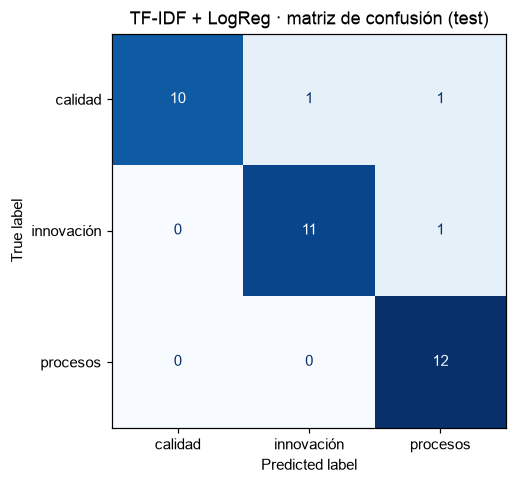

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix(test.line, pred_tfidf, labels=LINES), display_labels=["calidad", "innovación", "procesos"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("TF-IDF + LogReg · matriz de confusión (test)")
fig.tight_layout(); fig.savefig(OUT / "confusion-tfidf.png"); plt.show()

## 3. Sesgo y varianza: curva de aprendizaje

- **Sesgo alto** (el modelo es demasiado simple): accuracy baja tanto en entrenamiento como en validación.
- **Varianza alta** (memoriza): accuracy de entrenamiento muy alta y de validación mucho más baja.
- Si la curva de validación **sigue subiendo** al agregar datos, más datos ayudarían.

Validación cruzada estratificada de 5 particiones sobre el conjunto de entrenamiento (el test no se toca).

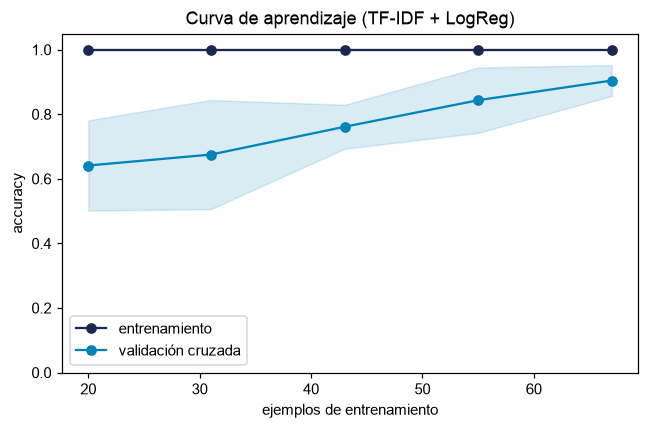

train acc por tamaño: [1. 1. 1. 1. 1.]
val acc por tamaño:   [0.641 0.675 0.761 0.843 0.904]


In [5]:
sizes, tr, va = learning_curve(clf, train.text, train.line, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                               train_sizes=np.linspace(0.3, 1.0, 5), scoring="accuracy")
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sizes, tr.mean(1), "o-", color="#1A2850", label="entrenamiento")
ax.plot(sizes, va.mean(1), "o-", color="#0283BA", label="validación cruzada")
ax.fill_between(sizes, va.mean(1) - va.std(1), va.mean(1) + va.std(1), color="#0283BA", alpha=0.15)
ax.set_xlabel("ejemplos de entrenamiento"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.05); ax.legend(); ax.set_title("Curva de aprendizaje (TF-IDF + LogReg)")
fig.tight_layout(); fig.savefig(OUT / "learning-curve.png"); plt.show()
print("train acc por tamaño:", tr.mean(1).round(3)); print("val acc por tamaño:  ", va.mean(1).round(3))

## 4. LLM: Claude Haiku 4.5, zero-shot y few-shot

- **Zero-shot:** solo la definición de las 3 líneas.
- **Few-shot:** además, 2 ejemplos por línea tomados del conjunto de **entrenamiento** (nunca del test).
- `temperature=0` y respuesta de una sola palabra: el id de la línea. Ojo: el SDK de Python 1.x **eliminó** `temperature` de su firma (la API la sigue aceptando en Haiku 4.5), así que se envía con `extra_body`.
- Costo = tokens reales de cada llamada × precio de Haiku 4.5 (US$ 1 / 5 por millón de tokens de entrada / salida, consultado el 2026-09-29).

In [6]:
import anthropic
client = anthropic.Anthropic()
HAIKU = "claude-haiku-4-5-20251001"
PRICE_IN, PRICE_OUT = 1.0, 5.0  # USD / MTok

SYSTEM = """Clasificas solicitudes de MIPYMES en UNA línea de trabajo de un centro de innovación.
- quality_assurance: aseguramiento de la calidad (defectos, devoluciones, estándares, certificaciones, procedimientos, capacitación en seguridad).
- business_innovation: innovación y desarrollo empresarial (productos nuevos, prototipos, propiedad intelectual, financiación de proyectos, transformación digital o IA).
- process_design: diseño, mejora y sostenibilidad de procesos (filas, capacidad, cuellos de botella, desperdicios, procesos en papel o WhatsApp, inventarios, indicadores).
Responde SOLO con el id de la línea."""

shots = pd.concat([g.sample(2, random_state=1) for _, g in train.groupby("line")])
FEW = [m for _, r in shots.iterrows() for m in ({"role": "user", "content": r.text}, {"role": "assistant", "content": r.line})]

def classify(text, few_shot=False):
    msgs = (FEW if few_shot else []) + [{"role": "user", "content": text}]
    s = time.perf_counter()
    # SDK 1.x removed `temperature` from the signature; Haiku 4.5 still honours it, so it goes in extra_body.
    r = client.messages.create(model=HAIKU, max_tokens=12, system=SYSTEM, messages=msgs, extra_body={"temperature": 0})
    ms = (time.perf_counter() - s) * 1000
    out = r.content[0].text.strip()
    m = re.search("|".join(LINES), out)
    return (m.group(0) if m else "invalida"), ms, r.usage.input_tokens, r.usage.output_tokens

results = {}
for name, few in [("Haiku zero-shot", False), ("Haiku few-shot", True)]:
    rows = [classify(t, few) for t in test.text]
    preds = [r[0] for r in rows]
    tin = np.mean([r[2] for r in rows]); tout = np.mean([r[3] for r in rows])
    results[name] = {
        "name": name,
        "accuracy": accuracy_score(test.line, preds),
        "macro_f1": f1_score(test.line, preds, average="macro"),
        "latency_ms_p50": float(np.median([r[1] for r in rows])),
        "avg_input_tokens": float(tin), "avg_output_tokens": float(tout),
        "cost_per_1000_usd": 1000 * (tin * PRICE_IN + tout * PRICE_OUT) / 1e6,
        "invalid": int(sum(p == "invalida" for p in preds)),
        "preds": preds,
    }
    print(name, {k: round(v, 4) if isinstance(v, float) else v for k, v in results[name].items() if k != "preds"})

Haiku zero-shot {'name': 'Haiku zero-shot', 'accuracy': 0.8611, 'macro_f1': 0.8614, 'latency_ms_p50': 613.3318, 'avg_input_tokens': 270.5, 'avg_output_tokens': 6.2222, 'cost_per_1000_usd': np.float64(0.3016), 'invalid': 0}


Haiku few-shot {'name': 'Haiku few-shot', 'accuracy': 0.9722, 'macro_f1': 0.9722, 'latency_ms_p50': 527.6677, 'avg_input_tokens': 991.5, 'avg_output_tokens': 6.3333, 'cost_per_1000_usd': np.float64(1.0232), 'invalid': 0}


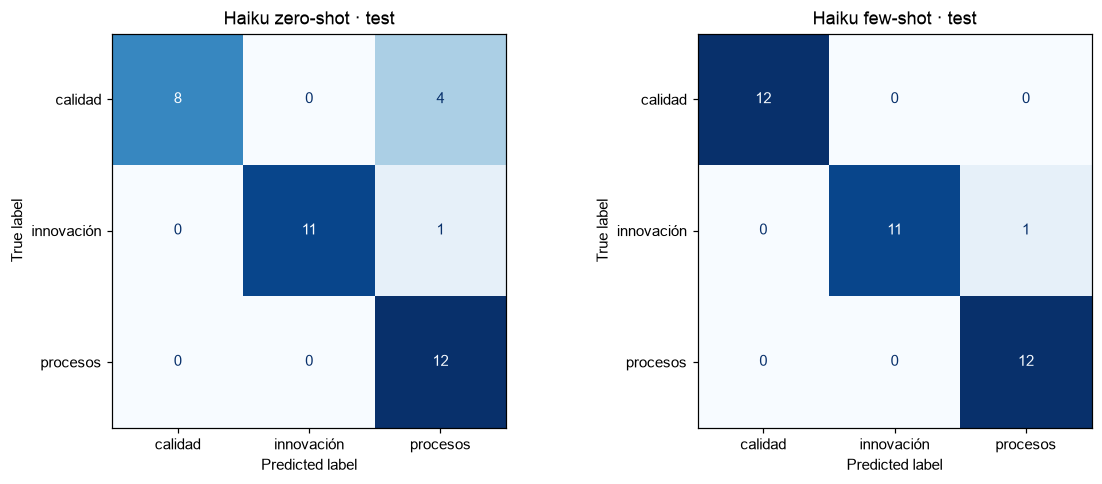

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, results):
    ConfusionMatrixDisplay(confusion_matrix(test.line, results[name]["preds"], labels=LINES), display_labels=["calidad", "innovación", "procesos"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} · test")
fig.tight_layout(); fig.savefig(OUT / "confusion-llm.png"); plt.show()

## 5. Errores: ¿en qué se equivocan?

In [8]:
err = test.assign(tfidf=pred_tfidf, zero=results["Haiku zero-shot"]["preds"], few=results["Haiku few-shot"]["preds"])
wrong = err[(err.tfidf != err.line) | (err.zero != err.line) | (err.few != err.line)]
pd.set_option("display.max_colwidth", 140)
wrong[["id", "line", "tfidf", "zero", "few", "text"]]

,id,line,tfidf,zero,few,text
23,qua-024,quality_assurance,quality_assurance,process_design,quality_assurance,En el hotel boutique del Centro Histórico los huéspedes reclaman porque el aseo de las habitaciones no es igual todos los días. Tenemos ...
15,qua-016,quality_assurance,quality_assurance,process_design,quality_assurance,"Estimados, somos un hotel boutique en el centro histórico de Cartagena con 22 empleados. Hemos recibido quejas de huéspedes por diferenc..."
24,qua-025,quality_assurance,process_design,process_design,quality_assurance,"Pescamos y vendemos en Bocachica, y parte del pescado llega dañado a los clientes por la cadena de frío. Somos 5 y necesitamos un contro..."
62,bus-023,business_innovation,process_design,process_design,process_design,"Buenos días. Soy dueña de un taller de confección en El Carmen de Bolívar con 25 costureras. Hacemos uniformes escolares y de empresas, ..."
22,qua-023,quality_assurance,business_innovation,quality_assurance,quality_assurance,"Queremos certificarnos en ISO 9001 para vender a hoteles grandes, pero somos 12 personas y no sabemos por dónde empezar."
20,qua-021,quality_assurance,quality_assurance,process_design,quality_assurance,"Somos una panadería en Turbaco con 6 empleados y el pan sale diferente según el turno, unos días queda crudo y otros quemado. ¿Nos puede..."


## 6. Comparación final (mismo conjunto de prueba)

In [9]:
models = [tfidf] + [{k: v for k, v in r.items() if k != "preds"} for r in results.values()]
table = pd.DataFrame(models)[["name", "accuracy", "macro_f1", "cost_per_1000_usd", "latency_ms_p50"]]
display(table.round(4))
(OUT / "comparacion.json").write_text(json.dumps({
    "generated_by": "ml/clasificador.ipynb",
    "data": "ml/data/requests_labeled.csv (SINTÉTICO, 120 filas)",
    "n_train": len(train), "n_test": len(test), "split_seed": 42,
    "models": models,
}, ensure_ascii=False, indent=2))
print("saved", OUT / "comparacion.json")

,name,accuracy,macro_f1,cost_per_1000_usd,latency_ms_p50
0,TF-IDF + LogReg,0.9167,0.9163,0.0000,0.6449
1,Haiku zero-shot,0.8611,0.8614,0.3016,613.3318
2,Haiku few-shot,0.9722,0.9722,1.0232,527.6677


saved /Users/felmco/Documents/aiengineering/ai-engineering-demo/ml/results/comparacion.json


## Conclusión

La decisión (qué se usa en producción y por qué) está en [`docs/adr/0005-clasificador.md`](../docs/adr/0005-clasificador.md), escrita a partir de la tabla anterior. Recordatorio: con 36 casos de prueba sintéticos, **una diferencia de 1 caso equivale a ~2,8 puntos de accuracy**; diferencias pequeñas no son concluyentes.